# Bayesian Optimization using GPR with derivative observations

In [1]:
from gpder import BayesianOptimization

In [2]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

bounds = np.array([[0.0, 5.0]])
noise = 0.2

def f(X, noise_level=0.2):
    #return X*np.sin(X) + noise_level * np.random.randn(*X.shape)
    return np.sin(X)

def df(X):
    #return X*np.cos(X) + np.sin(X)
    return np.cos(X)

X_init = np.array([[1], [2.5]])
Y_init = f(X_init)
dX_init = np.array([[1], [2.5]])
dY_init = df(dX_init)

In [3]:
# Dense grid of points within bounds
X = np.arange(bounds[:, 0], bounds[:, 1], 0.01).reshape(-1, 1)

# Noise-free objective function values at X 
Y = f(X,0)

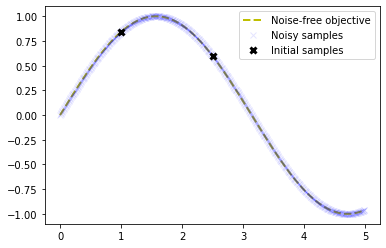

In [4]:
# Plot optimization objective with noise level 
plt.plot(X, Y, 'y--', lw=2, label='Noise-free objective')
plt.plot(X, f(X), 'bx', lw=1, alpha=0.1, label='Noisy samples')
plt.plot(X_init, Y_init, 'kx', mew=3, label='Initial samples')
plt.legend();

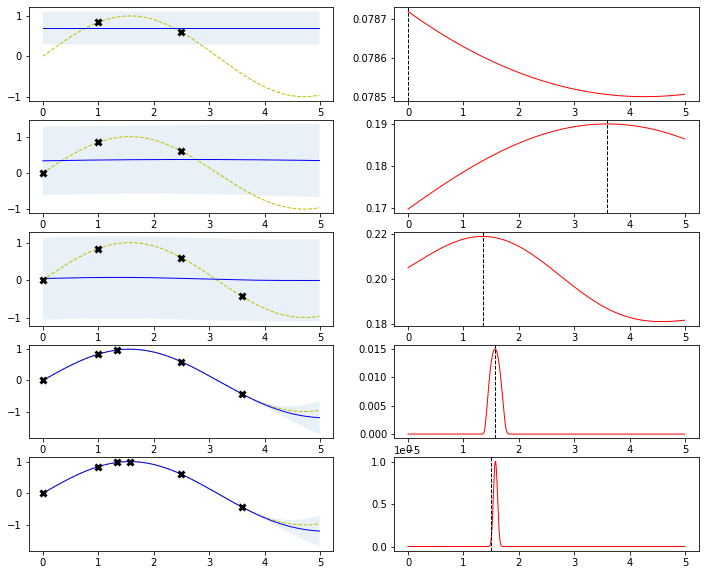

In [5]:
BayesianOptimization(n_iters=5,
                     X=X.reshape(-1, 1), y=Y,
                     f=f, 
                     X_sample=X_init.reshape(-1, 1), y_sample=Y_init,
                     #df=df,  
                     #dX_sample=dX_init.reshape(-1, 1), dy_sample=dY_init,
                     bounds=bounds, random_state=123)

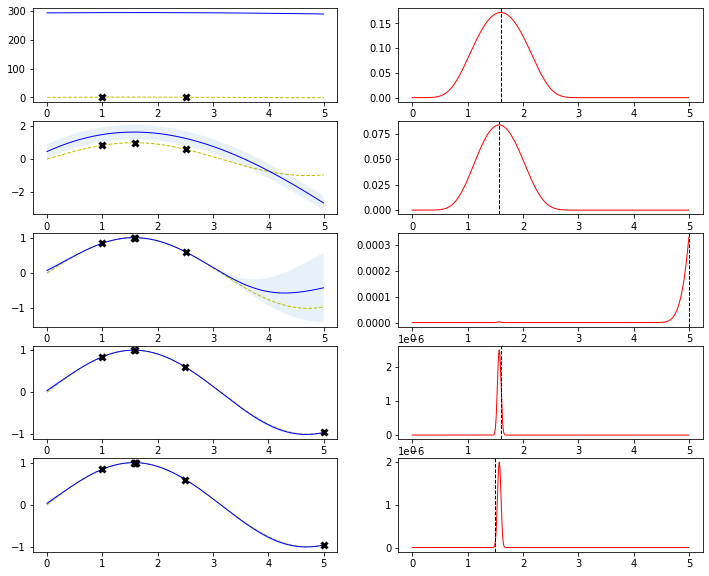

In [6]:
BayesianOptimization(n_iters=5,
                     X=X.reshape(-1, 1), y=Y,
                     f=f, 
                     X_sample=X_init.reshape(-1, 1), y_sample=Y_init,
                     df=df,  
                     dX_sample=dX_init.reshape(-1, 1), dy_sample=dY_init,
                     bounds=bounds, random_state=123)